<a href="https://colab.research.google.com/github/tanisham2/AI-Expense-Tracker/blob/main/FinanceProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset1')

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset2')

print("Done")

Done


In [2]:
import os

print("Dataset 1:")
for root, dirs, files in os.walk('/content/dataset1'):
    for file in files:
        print(os.path.join(root, file))

print("\nDataset 2:")
for root, dirs, files in os.walk('/content/dataset2'):
    for file in files:
        print(os.path.join(root, file))

Dataset 1:
/content/dataset1/budgetwise_synthetic_dirty.csv
/content/dataset1/budgetwise_finance_dataset.csv

Dataset 2:
/content/dataset2/Daily Household Transactions.csv


In [3]:
import pandas as pd

df1 = pd.read_csv('/content/dataset1/budgetwise_finance_dataset.csv')
df2 = pd.read_csv('/content/dataset2/Daily Household Transactions.csv')

In [4]:
print(df1.columns.tolist())
print(df2.columns.tolist())

['transaction_id', 'user_id', 'date', 'transaction_type', 'category', 'amount', 'payment_mode', 'location', 'notes']
['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount', 'Income/Expense', 'Currency']


In [5]:
df1.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


In [6]:
df2.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [7]:
print(df1.shape)
print(df2.shape)

(15900, 9)
(2461, 8)


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15900 non-null  object
 1   user_id           15900 non-null  object
 2   date              15414 non-null  object
 3   transaction_type  15900 non-null  object
 4   category          15615 non-null  object
 5   amount            15609 non-null  object
 6   payment_mode      15092 non-null  object
 7   location          14638 non-null  object
 8   notes             13079 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [10]:
df1_clean = df1[['date', 'category', 'amount', 'notes', 'transaction_type', 'payment_mode']].copy()

df2_clean = df2[['Date', 'Category', 'Amount', 'Note', 'Income/Expense', 'Mode']].copy()

df2_clean.columns = [  'date',
    'category',
    'amount',
    'notes',
    'transaction_type',
    'payment_mode'
]

combined_df = pd.concat([df1_clean, df2_clean], ignore_index=True)

print(combined_df.shape)
combined_df.head()

(18361, 6)


,date,category,amount,notes,transaction_type,payment_mode
0,2023-04-25,Educaton,3888,Movie tickets,Expense,card
1,08/05/2022,rent,649,asdfgh,Expense,NaN
2,31-12-23,Freelance,13239,Books,Income,Csh
3,NaN,Fod,6299,Electricity bill,Expense,Bank Transfer
4,10/28/2022,entertainment,2287,NaN,Expense,CARD


In [11]:
combined_df['notes'] = combined_df['notes'].fillna('unknown')
combined_df['category'] = combined_df['category'].fillna('unknown')
combined_df['payment_mode'] = combined_df['payment_mode'].fillna('unknown')

combined_df = combined_df.dropna(subset=['amount'])

In [12]:
combined_df.to_csv('final_expense_dataset.csv', index=False)

print("Dataset saved!")

Dataset saved!


In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18070 entries, 0 to 18360
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              17590 non-null  object
 1   category          18070 non-null  object
 2   amount            18070 non-null  object
 3   notes             18070 non-null  object
 4   transaction_type  18070 non-null  object
 5   payment_mode      18070 non-null  object
dtypes: object(6)
memory usage: 988.2+ KB


In [14]:
combined_df.head()

,date,category,amount,notes,transaction_type,payment_mode
0,2023-04-25,Educaton,3888,Movie tickets,Expense,card
1,08/05/2022,rent,649,asdfgh,Expense,unknown
2,31-12-23,Freelance,13239,Books,Income,Csh
3,NaN,Fod,6299,Electricity bill,Expense,Bank Transfer
4,10/28/2022,entertainment,2287,unknown,Expense,CARD


In [15]:
combined_df['amount'] = pd.to_numeric(combined_df['amount'], errors='coerce')
combined_df = combined_df.dropna(subset=['amount'])

combined_df['category'] = combined_df['category'].str.lower()
combined_df = combined_df.dropna(subset=['date'])

print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14524 entries, 0 to 18360
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              14524 non-null  object 
 1   category          14524 non-null  object 
 2   amount            14524 non-null  float64
 3   notes             14524 non-null  object 
 4   transaction_type  14524 non-null  object 
 5   payment_mode      14524 non-null  object 
dtypes: float64(1), object(5)
memory usage: 794.3+ KB
None


In [16]:
print(combined_df['category'].value_counts().head(20))

category
food              2231
rent              1273
travel             924
entertainment      498
others             483
utilities          478
investment         467
health             451
foods              441
education          425
foodd              409
rentt              402
salary             398
fod                398
rnt                394
freelance          360
bonus              343
transportation     307
traval             306
travl              274
Name: count, dtype: int64


In [17]:
print(combined_df['transaction_type'].value_counts())

transaction_type
Expense         12411
Income           1953
Transfer-Out      160
Name: count, dtype: int64


In [18]:
print(combined_df['payment_mode'].value_counts())

payment_mode
Cash                     1639
Saving Bank account 1    1223
UPI                       709
upi                       705
Upi                       699
UPi                       640
Bank Transfr              617
unknown                   610
CARD                      607
card                      590
bank transfer             583
Card                      583
BankTransfer              580
CRD                       579
csh                       577
Bank Transfer             576
cash                      572
Csh                       565
Crd                       565
Bank_Transfer             563
CASH                      550
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64


In [19]:
payment_map = {
    'cash': 'Cash',
    'CASH': 'Cash',
    'csh': 'Cash',
    'Csh': 'Cash',

    'upi': 'UPI',
    'Upi': 'UPI',
    'UPi': 'UPI',

    'card': 'Card',
    'CARD': 'Card',
    'CRD': 'Card',
    'Crd': 'Card',
    'Credit Card': 'Card',
    'Debit Card': 'Card',

    'bank transfer': 'Bank Transfer',
    'BankTransfer': 'Bank Transfer',
    'Bank_Transfer': 'Bank Transfer',
    'Bank Transfr': 'Bank Transfer'
}

combined_df['payment_mode'] = combined_df['payment_mode'].replace(payment_map)

In [20]:
print(combined_df['payment_mode'].value_counts())

payment_mode
Cash                     3903
Card                     3088
Bank Transfer            2919
UPI                      2753
Saving Bank account 1    1223
unknown                   610
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64


In [21]:
combined_df['payment_mode'] = combined_df['payment_mode'].replace({
    'Saving Bank account 1': 'Bank Account',
    'Saving Bank account 2': 'Bank Account'
})

In [22]:
print(combined_df['payment_mode'].value_counts())

payment_mode
Cash                    3903
Card                    3088
Bank Transfer           2919
UPI                     2753
Bank Account            1228
unknown                  610
Equity Mutual Fund B      11
Share Market Trading       5
Recurring Deposit          3
Equity Mutual Fund C       1
Equity Mutual Fund A       1
Equity Mutual Fund D       1
Fixed Deposit              1
Name: count, dtype: int64


In [23]:
rare_modes = [
    'Equity Mutual Fund A',
    'Equity Mutual Fund B',
    'Equity Mutual Fund C',
    'Equity Mutual Fund D',
    'Share Market Trading',
    'Recurring Deposit',
    'Fixed Deposit'
]

combined_df['payment_mode'] = combined_df['payment_mode'].replace(
    rare_modes,
    'Investment'
)

In [24]:
category_map = {
    'foods': 'food',
    'foodd': 'food',
    'fod': 'food',

    'rentt': 'rent',
    'rnt': 'rent',

    'traval': 'travel',
    'travl': 'travel',

    'entertain': 'entertainment',
    'entrtnmnt': 'entertainment',

    'utlities': 'utility',
    'utilties': 'utility',

    'edu': 'education',
    'educaton': 'education',

    'helth': 'health',
    'other': 'others',
    'saving': 'savings'
}

combined_df['category'] = combined_df['category'].replace(category_map)

In [25]:
print(combined_df['category'].value_counts().head(20))

category
food              3479
rent              2069
travel            1504
entertainment     1016
education          782
utility            717
others             646
health             573
utilities          478
investment         467
salary             398
freelance          360
bonus              343
transportation     307
savings            295
unknown            202
household          176
subscription       143
family              71
apparel             47
Name: count, dtype: int64


In [26]:
combined_df[['notes', 'category']].sample(20)

,notes,category
16967,2 Place 2 to Place 1 - Shree Sharma Travels,transportation
17909,unknown,investment
3008,test,food
9617,Grocery shopping,travel
16988,unknown,subscription
10552,Grocery shopping,bonus
15180,Coffee,entertainment
4541,misc,entertainment
951,Internet bill,food
14478,Coffee,food


In [27]:
combined_df['notes'].value_counts().head(30)

,count
notes,
unknown,2628
Electricity bill,432
Monthly rent payment,428
ATM withdrawal,423
Movie tickets,409
Grocery shopping,402
Coffee,401
Gym membership,399
xyz123,394


In [28]:
combined_df.groupby('notes')['category'].nunique().sort_values(ascending=False).head(20)

,category
notes,
unknown,45
Books,16
EMI payment,16
Doctor consultation,16
Coffee,16
Petrol,16
Restaurant dinner,16
Online course,16
Internet bill,16


In [29]:
print("Unique notes:", combined_df['notes'].nunique())

Unique notes: 1084


In [30]:
combined_df['notes'].value_counts().head(100)

,count
notes,
unknown,2628
Electricity bill,432
Monthly rent payment,428
ATM withdrawal,423
Movie tickets,409
...,...
Station Parking,4
cutting chai,4
Amul butter,4


In [31]:
combined_df.groupby(['notes', 'category']).size().reset_index(name='count').sort_values(['notes','count'], ascending=[True, False])

,notes,category,count
0,courier,others,1
1,monument,culture,1
2,mutual fund,investment,9
3,pedhe,food,2
7,!!!,food,74
...,...,...,...
1518,xyz123,health,11
1513,xyz123,bonus,10
1524,xyz123,savings,7
1520,xyz123,misc,2


In [32]:
note_category_counts = combined_df.groupby('notes')['category'].nunique()
conflicted_notes = note_category_counts[note_category_counts > 1].index
print(f"Notes mapping to multiple categories: {len(conflicted_notes)}")
print(conflicted_notes.tolist())

Notes mapping to multiple categories: 46
['!!!', '...', 'ATM withdrawal', 'Amul butter', 'Books', 'Coffee', 'Courier', 'Doctor consultation', 'EMI payment', 'Electricity bill', 'Family Mobile Service Provider recharge', 'Fixed deposit', 'From Family', 'Grocery shopping', 'Gym membership', 'Internet bill', 'Lumpsum', 'Lunch', 'Marathon', 'Medicine', 'Mobile Service Provider recharge 365 days', 'Mobile Service Provider recharge wfh', 'Monthly rent payment', 'Movie tickets', 'Nariyal', 'Online course', 'Petrol', 'Restaurant dinner', 'Shopping', 'To Family', 'Train ticket', 'Uber ride', 'asdfgh', 'audible subscription', 'flour mill', 'hair cut', 'hair cut+shaving', 'kindle unlimited', 'misc', 'moscuito racket', 'reward Gpay', 'shoe polish', 'test', 'unknown', 'water jar', 'xyz123']


In [33]:
dominant_category = (
    combined_df.groupby(['notes', 'category'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates(subset='notes', keep='first')
    .set_index('notes')['category']
)

combined_df['category'] = combined_df.apply(
    lambda row: dominant_category[row['notes']]
    if row['notes'] in conflicted_notes
    else row['category'],
    axis=1
)

In [34]:
combined_df.groupby('notes')['category'].nunique().sort_values(ascending=False).head(20)

,category
notes,
yevle amrutullya,1
courier,1
monument,1
mutual fund,1
pedhe,1
!!!,1
( pav bhaji + 2 extra pav + sabudana khichdi + kothimbir vada + masala bhat + piyush ),1
...,1
1 Jar,1


In [35]:
combined_df[
    combined_df['notes'].isin([
        'Movie tickets',
        'Coffee',
        'Petrol',
        'Electricity bill'
    ])
][['notes','category']].drop_duplicates()

,notes,category
0,Movie tickets,food
13,Electricity bill,food
30,Coffee,food
68,Petrol,food


In [36]:
manual_map = {
    'Movie tickets': 'entertainment',
    'Electricity bill': 'utility',
    'Petrol': 'transportation',
    'Coffee': 'food',
    'Doctor consultation': 'health',
    'Medicine': 'health',
    'Monthly rent payment': 'rent',
    'Internet bill': 'utility',
    'Online course': 'education',
    'Train ticket': 'travel',
    'Uber ride': 'travel',
    'Gym membership': 'health',
    'Restaurant dinner': 'food'
}

In [37]:
combined_df['category'] = combined_df.apply(
    lambda row: manual_map.get(row['notes'], row['category']),
    axis=1
)

In [38]:
combined_df[
    combined_df['notes'].isin([
        'Movie tickets',
        'Coffee',
        'Petrol',
        'Electricity bill',
        'Doctor consultation',
        'Monthly rent payment'
    ])
][['notes', 'category']].drop_duplicates()

,notes,category
0,Movie tickets,entertainment
13,Electricity bill,utility
30,Coffee,food
51,Doctor consultation,health
68,Petrol,transportation
80,Monthly rent payment,rent


In [39]:
combined_df[
    combined_df['notes'].isin(manual_map.keys())
][['notes', 'category']].drop_duplicates().sort_values('notes')

,notes,category
30,Coffee,food
51,Doctor consultation,health
13,Electricity bill,utility
9,Gym membership,health
33,Internet bill,utility
54,Medicine,health
80,Monthly rent payment,rent
0,Movie tickets,entertainment
35,Online course,education
68,Petrol,transportation


In [40]:
combined_df[combined_df['notes'] == 'Movie tickets'][['notes', 'category']].drop_duplicates()

,notes,category
0,Movie tickets,entertainment


In [41]:
combined_df.groupby('notes')['category'].nunique().sort_values(ascending=False).head(10)

,category
notes,
yevle amrutullya,1
courier,1
monument,1
mutual fund,1
pedhe,1
!!!,1
( pav bhaji + 2 extra pav + sabudana khichdi + kothimbir vada + masala bhat + piyush ),1
...,1
1 Jar,1


In [42]:
invalid_notes = [
    '!!!',
    '...',
    'unknown',
    'asdfgh',
    'test',
    'xyz123',
    'misc'
]

combined_df = combined_df[
    ~combined_df['notes'].isin(invalid_notes)
]

In [43]:
combined_df = combined_df[
    combined_df['notes'].notna()
]

In [44]:
print("Unique notes:", combined_df['notes'].nunique())
print("Rows:", len(combined_df))

Unique notes: 1077
Rows: 9599


In [45]:
combined_df['notes'].value_counts().head(30)

,count
notes,
Electricity bill,432
Monthly rent payment,428
ATM withdrawal,423
Movie tickets,409
Grocery shopping,402
Coffee,401
Gym membership,399
Internet bill,387
Doctor consultation,384


In [46]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

combined_df['clean_notes'] = combined_df['notes'].apply(clean_text)

In [47]:
combined_df[['notes', 'clean_notes', 'category']].sample(20)

,notes,clean_notes,category
15527,Petrol,petrol,transportation
16041,4 kachori,4 kachori,food
17138,2 Current Residence to Place 0,2 current residence to place 0,transportation
17775,bread,bread,food
5993,Doctor consultation,doctor consultation,health
5931,Doctor consultation,doctor consultation,health
7620,Fixed deposit,fixed deposit,food
8173,Internet bill,internet bill,utility
17925,audible subscription,audible subscription,others
6272,ATM withdrawal,atm withdrawal,food


In [48]:
combined_df[['notes', 'clean_notes', 'category']].drop_duplicates().sample(20)

,notes,clean_notes,category
15908,HBR 2 Months subscription,hbr 2 months subscription,others
17313,2 Place 0 to WS single,2 place 0 to ws single,transportation
15913,Home Food Delivery,home food delivery,food
18330,participation fee - corporate cricket league,participation fee corporate cricket league,others
17404,2 Spike guard,2 spike guard,household
17125,New FD opened for 3 years,new fd opened for 3 years,fixed deposit
17338,Family's Wristwatch repair,familys wristwatch repair,others
17918,pedhe,pedhe,food
18355,ropeway Place T to and fro,ropeway place t to and fro,transportation
17286,Double omlet pav + tea,double omlet pav tea,food


In [49]:
nlp_df = combined_df[['clean_notes', 'category']].drop_duplicates()

In [50]:
print(nlp_df.shape)
print(nlp_df.head())

(1068, 2)
          clean_notes       category
0       movie tickets  entertainment
2               books           food
9      gym membership         health
13   electricity bill        utility
14  restaurant dinner           food


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [52]:
X = nlp_df['clean_notes']
y = nlp_df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [54]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000))])

In [55]:
y_pred = model.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5934579439252337


In [57]:
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

                  apparel       0.00      0.00      0.00         4
                   beauty       0.00      0.00      0.00         1
                    bonus       0.00      0.00      0.00         2
                  culture       0.00      0.00      0.00         1
dividend earned on shares       1.00      1.00      1.00         2
                documents       0.00      0.00      0.00         1
                education       0.00      0.00      0.00         4
                   family       0.00      0.00      0.00         4
                festivals       0.00      0.00      0.00         1
            fixed deposit       0.00      0.00      0.00         1
                     food       0.49      1.00      0.66        80
                     gift       0.00      0.00      0.00         4
                   health       1.00      0.17      0.29        12
                household       0.75      0.10      0.18     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
model.predict([
    "movie tickets",
    "doctor consultation",
    "monthly rent payment",
    "internet bill",
    "uber ride"
])

array(['food', 'food', 'food', 'food', 'food'], dtype=object)

In [59]:
nlp_df['category'].value_counts()

,count
category,
food,421
transportation,185
household,115
others,86
health,68
apparel,33
subscription,27
family,21
gift,16


In [60]:
nlp_df = combined_df[['clean_notes', 'category']]

In [61]:
nlp_df['category'].value_counts()

,count
category,
food,4246
health,1231
utility,819
travel,738
transportation,648
rent,428
entertainment,409
education,382
household,159


In [62]:
combined_df['category'] = combined_df['category'].replace({
    'transportation': 'travel',
    'tourism': 'travel'
})

In [63]:
category_counts = combined_df['category'].value_counts()

valid_categories = category_counts[
    category_counts >= 20
].index

nlp_df = combined_df[
    combined_df['category'].isin(valid_categories)
][['clean_notes', 'category']]

In [64]:
nlp_df['category'].value_counts()

,count
category,
food,4246
travel,1391
health,1231
utility,819
rent,428
entertainment,409
education,382
household,159
others,120


In [65]:
X = nlp_df['clean_notes']
y = nlp_df['category']

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000))])

In [68]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9652814308258811
               precision    recall  f1-score   support

      apparel       1.00      0.44      0.62         9
       beauty       1.00      0.80      0.89         5
    education       1.00      0.96      0.98        79
entertainment       1.00      1.00      1.00        87
       family       0.00      0.00      0.00         3
         food       0.93      1.00      0.96       832
         gift       1.00      0.33      0.50         6
       health       1.00      0.96      0.98       255
    household       0.67      0.23      0.34        26
   investment       1.00      0.94      0.97        16
       others       1.00      0.18      0.30        17
         rent       1.00      1.00      1.00        86
       salary       1.00      1.00      1.00         7
 subscription       0.94      0.89      0.92        19
       travel       1.00      0.99      0.99       283
      utility       1.00      1.00      1.00       171

     accuracy                     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
model.predict([
    "movie tickets",
    "doctor consultation",
    "monthly rent payment",
    "internet bill",
    "uber ride"
])

array(['entertainment', 'health', 'rent', 'utility', 'travel'],
      dtype=object)

In [70]:
import joblib

joblib.dump(model, 'expense_category_model.pkl')

['expense_category_model.pkl']

In [71]:
combined_df.to_csv('cleaned_expense_data.csv', index=False)

In [72]:
import pandas as pd

combined_df = pd.read_csv('cleaned_expense_data.csv')

In [73]:
combined_df.shape

(9599, 7)

In [74]:
combined_df.columns

Index(['date', 'category', 'amount', 'notes', 'transaction_type',
       'payment_mode', 'clean_notes'],
      dtype='object')

In [75]:
combined_df['date'] = pd.to_datetime(
    combined_df['date'],
    errors='coerce'
)

In [76]:
combined_df['year'] = combined_df['date'].dt.year
combined_df['month'] = combined_df['date'].dt.month
combined_df['day'] = combined_df['date'].dt.day
combined_df['weekday'] = combined_df['date'].dt.day_name()

In [77]:
combined_df.head()

,date,category,amount,notes,transaction_type,payment_mode,clean_notes,year,month,day,weekday
0,2023-04-25,entertainment,3888.0,Movie tickets,Expense,Card,movie tickets,2023.0,4.0,25.0,Tuesday
1,NaT,food,13239.0,Books,Income,Cash,books,NaN,NaN,NaN,NaN
2,NaT,health,59543.0,Gym membership,Income,UPI,gym membership,NaN,NaN,NaN,NaN
3,NaT,utility,23760.0,Electricity bill,Expense,Card,electricity bill,NaN,NaN,NaN,NaN
4,NaT,food,898.0,Restaurant dinner,Expense,UPI,restaurant dinner,NaN,NaN,NaN,NaN


In [78]:
combined_df = combined_df[
    combined_df['amount'] != 999999999
]

In [79]:
combined_df = combined_df[
    combined_df['amount'] >= 0
]

In [80]:
combined_df.shape

(9496, 11)

In [81]:
combined_df['amount'].describe()

,amount
count,9496.000000
mean,17486.359434
std,80333.207943
min,0.000000
25%,1000.000000
50%,4373.500000
75%,8733.750000
max,999999.000000


In [82]:
combined_df.nlargest(20, 'amount')[
    ['date', 'amount', 'category', 'notes']
]

,date,amount,category,notes
1021,2024-11-24,999999.0,utility,Electricity bill
1067,NaT,999999.0,food,Books
1088,2021-06-10,999999.0,food,Coffee
1107,2022-11-19,999999.0,food,Coffee
1241,NaT,999999.0,health,Medicine
1318,NaT,999999.0,food,Books
1392,2022-06-17,999999.0,travel,Train ticket
1421,2024-08-08,999999.0,travel,Petrol
1601,2024-02-07,999999.0,food,Fixed deposit
1908,2022-02-23,999999.0,food,Coffee


In [83]:
(combined_df['amount'] == 999999).sum()

np.int64(47)

In [84]:
combined_df = combined_df[
    combined_df['amount'] != 999999
]

In [85]:
combined_df['amount'].describe()

,amount
count,9449.000000
mean,12599.271477
std,40737.052208
min,0.000000
25%,1000.000000
50%,4333.000000
75%,8668.000000
max,978324.000000


In [86]:
combined_df.nlargest(10, 'amount')[
    ['date', 'amount', 'category', 'notes']
]

,date,amount,category,notes
5569,2023-09-24,978324.0,food,Grocery shopping
4668,2023-05-22,950787.0,utility,Internet bill
1427,2024-12-05,892217.0,entertainment,Movie tickets
5728,NaT,816412.0,health,Medicine
1225,NaT,816014.0,food,Coffee
4549,2022-04-01,808527.0,food,Fixed deposit
2491,NaT,778549.0,food,Fixed deposit
367,2021-12-20,749253.0,utility,Electricity bill
1314,NaT,717851.0,health,Medicine
4542,2024-05-10,709506.0,food,Grocery shopping


In [87]:
combined_df[combined_df['amount'] > 100000].shape

(59, 11)

In [88]:
combined_df[combined_df['amount'] > 100000][
    ['amount', 'category', 'notes']
].head(15)

,amount,category,notes
142,178518.0,food,Shopping
180,224611.0,entertainment,Movie tickets
181,174110.0,health,Gym membership
329,222939.0,health,Gym membership
367,749253.0,utility,Electricity bill
440,248568.0,health,Medicine
494,157969.0,entertainment,Movie tickets
818,360058.0,travel,Petrol
864,285939.0,utility,Electricity bill
908,581306.0,travel,Train ticket


In [89]:
combined_df = combined_df[
    combined_df['amount'] <= 100000
]

In [90]:
combined_df['amount'].describe()

,amount
count,9390.000000
mean,10076.889158
std,16528.948470
min,0.000000
25%,1000.000000
50%,4302.500000
75%,8572.500000
max,100000.000000


In [91]:
monthly_expense = combined_df.groupby(
    ['year', 'month']
)['amount'].sum().reset_index()

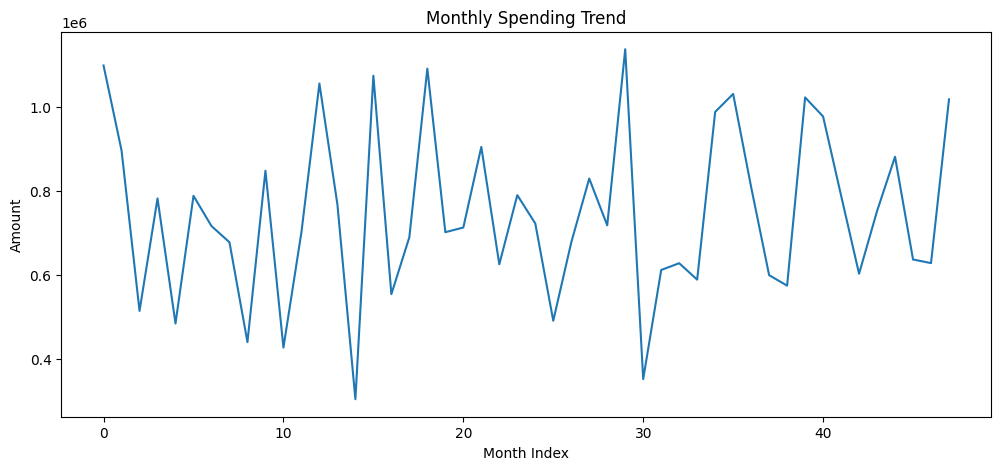

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_expense['amount'])
plt.title('Monthly Spending Trend')
plt.xlabel('Month Index')
plt.ylabel('Amount')
plt.show()

In [93]:
combined_df[combined_df['amount'] == 0].shape

(41, 11)

In [94]:
combined_df[combined_df['amount'] == 0][
    ['date','amount','category','notes']
].head(10)

,date,amount,category,notes
256,NaT,0.0,food,Restaurant dinner
462,NaT,0.0,utility,Internet bill
678,NaT,0.0,entertainment,Movie tickets
835,2024-09-02,0.0,food,Lunch
922,NaT,0.0,food,Grocery shopping
1204,NaT,0.0,food,Fixed deposit
1476,NaT,0.0,food,Fixed deposit
1980,NaT,0.0,food,ATM withdrawal
1992,2023-09-22,0.0,education,Online course
2125,NaT,0.0,food,Restaurant dinner


In [95]:
combined_df = combined_df[
    combined_df['amount'] > 0
]

In [96]:
combined_df.shape

(9349, 11)

In [97]:
monthly_expense = combined_df.groupby(
    ['year', 'month']
)['amount'].sum().reset_index()

In [98]:
monthly_expense.dtypes

,0
year,float64
month,float64
amount,float64


In [99]:
monthly_expense['date'] = pd.to_datetime(
    monthly_expense['year'].astype(int).astype(str) + '-' +
    monthly_expense['month'].astype(int).astype(str),
    format='%Y-%m'
)

In [100]:
monthly_expense.head()

,year,month,amount,date
0,2021.0,1.0,1099344.0,2021-01-01
1,2021.0,2.0,896959.0,2021-02-01
2,2021.0,3.0,514379.0,2021-03-01
3,2021.0,4.0,782418.0,2021-04-01
4,2021.0,5.0,484383.0,2021-05-01


In [101]:
monthly_expense.shape

(48, 4)

In [102]:
monthly_expense[['year','month']].tail(15)

,year,month
33,2023.0,10.0
34,2023.0,11.0
35,2023.0,12.0
36,2024.0,1.0
37,2024.0,2.0
38,2024.0,3.0
39,2024.0,4.0
40,2024.0,5.0
41,2024.0,6.0
42,2024.0,7.0


In [103]:
monthly_expense = monthly_expense.set_index('date')

In [104]:
monthly_expense.head()

,year,month,amount
date,,,
2021-01-01,2021.0,1.0,1099344.0
2021-02-01,2021.0,2.0,896959.0
2021-03-01,2021.0,3.0,514379.0
2021-04-01,2021.0,4.0,782418.0
2021-05-01,2021.0,5.0,484383.0


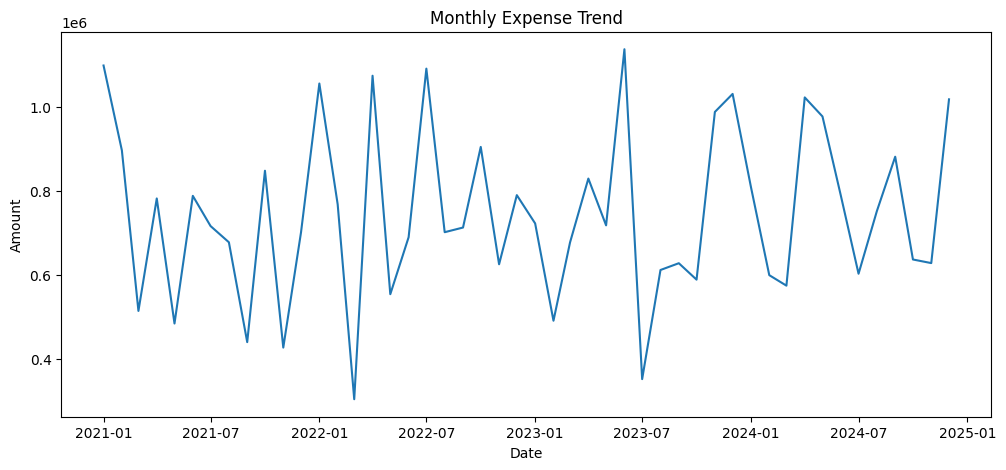

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_expense.index, monthly_expense['amount'])
plt.title("Monthly Expense Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

In [106]:
monthly_expense['amount'].describe()

,amount
count,4.800000e+01
mean,7.443588e+05
std,2.063681e+05
min,3.039240e+05
25%,6.097172e+05
50%,7.174925e+05
75%,8.856895e+05
max,1.138146e+06


In [107]:
train = monthly_expense.iloc[:-6]
test = monthly_expense.iloc[-6:]

In [108]:
train.shape

(42, 3)

In [109]:
test.shape

(6, 3)

In [110]:
train.index.min(), train.index.max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2024-06-01 00:00:00'))

In [111]:
test.index.min(), test.index.max()

(Timestamp('2024-07-01 00:00:00'), Timestamp('2024-12-01 00:00:00'))

In [112]:
from prophet import Prophet

prophet_train = train.reset_index()[['date', 'amount']]
prophet_train.columns = ['ds', 'y']

In [113]:
prophet_train.head()

,ds,y
0,2021-01-01,1099344.0
1,2021-02-01,896959.0
2,2021-03-01,514379.0
3,2021-04-01,782418.0
4,2021-05-01,484383.0


In [114]:
model = Prophet()
model.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [115]:
future = model.make_future_dataframe(
    periods=6,
    freq='MS'
)

In [116]:
forecast = model.predict(future)

In [117]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
38,2024-03-01,4.924524e+05,3.403210e+05,6.514104e+05
39,2024-04-01,9.566759e+05,8.029347e+05,1.122789e+06
40,2024-05-01,7.794622e+05,6.339380e+05,9.443853e+05
41,2024-06-01,7.076712e+05,5.453089e+05,8.717126e+05
42,2024-07-01,1.138332e+06,9.800854e+05,1.290176e+06
43,2024-08-01,8.686267e+05,7.106510e+05,1.023962e+06
44,2024-09-01,5.945471e+05,4.455839e+05,7.523618e+05
45,2024-10-01,1.264806e+06,1.105562e+06,1.417307e+06
46,2024-11-01,3.511832e+05,1.945438e+05,5.057152e+05
47,2024-12-01,6.948077e+05,5.362171e+05,8.614022e+05


In [118]:
test[['amount']]

,amount
date,
2024-07-01,603031.0
2024-08-01,752356.0
2024-09-01,881933.0
2024-10-01,636971.0
2024-11-01,628371.0
2024-12-01,1018688.0


In [119]:
forecast_test = forecast[['ds', 'yhat']].tail(6)
forecast_test = forecast_test.set_index('ds')
comparison = test[['amount']].copy()
comparison['predicted'] = forecast_test['yhat']

comparison

,amount,predicted
date,,
2024-07-01,603031.0,1.138332e+06
2024-08-01,752356.0,8.686267e+05
2024-09-01,881933.0,5.945471e+05
2024-10-01,636971.0,1.264806e+06
2024-11-01,628371.0,3.511832e+05
2024-12-01,1018688.0,6.948077e+05


In [120]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(
    comparison['amount'],
    comparison['predicted']
)

rmse = np.sqrt(
    np.mean(
        (comparison['amount'] - comparison['predicted'])**2
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 361310.13074282627
RMSE: 399700.9517372023


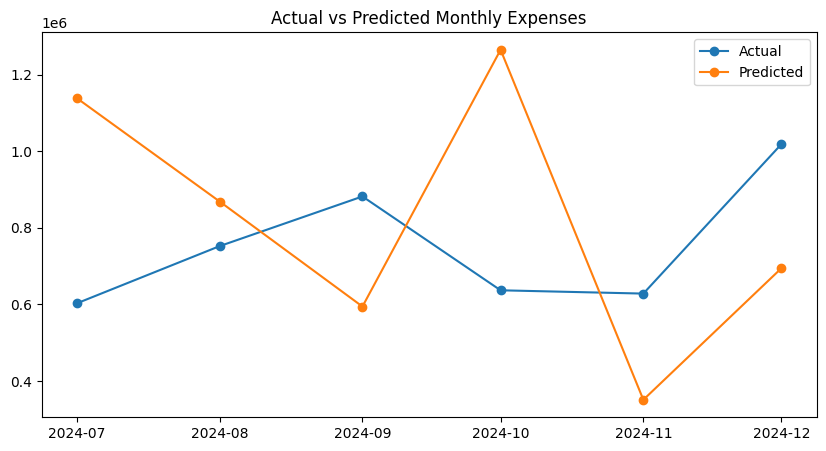

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    comparison.index,
    comparison['amount'],
    marker='o',
    label='Actual'
)

plt.plot(
    comparison.index,
    comparison['predicted'],
    marker='o',
    label='Predicted'
)

plt.title('Actual vs Predicted Monthly Expenses')
plt.legend()
plt.show()

In [122]:
xgb_df = monthly_expense.copy()

In [123]:
xgb_df['month_num'] = xgb_df.index.month
xgb_df['year_num'] = xgb_df.index.year
xgb_df['quarter'] = xgb_df.index.quarter

In [124]:
xgb_df['lag_1'] = xgb_df['amount'].shift(1)
xgb_df['lag_2'] = xgb_df['amount'].shift(2)
xgb_df['lag_3'] = xgb_df['amount'].shift(3)

In [125]:
xgb_df['rolling_3'] = xgb_df['amount'].rolling(3).mean()
xgb_df['rolling_6'] = xgb_df['amount'].rolling(6).mean()

In [126]:
xgb_df.head(10)

,year,month,amount,month_num,year_num,quarter,lag_1,lag_2,lag_3,rolling_3,rolling_6
date,,,,,,,,,,,
2021-01-01,2021.0,1.0,1099344.0,1,2021,1,NaN,NaN,NaN,NaN,NaN
2021-02-01,2021.0,2.0,896959.0,2,2021,1,1099344.0,NaN,NaN,NaN,NaN
2021-03-01,2021.0,3.0,514379.0,3,2021,1,896959.0,1099344.0,NaN,836894.000000,NaN
2021-04-01,2021.0,4.0,782418.0,4,2021,2,514379.0,896959.0,1099344.0,731252.000000,NaN
2021-05-01,2021.0,5.0,484383.0,5,2021,2,782418.0,514379.0,896959.0,593726.666667,NaN
2021-06-01,2021.0,6.0,788656.0,6,2021,2,484383.0,782418.0,514379.0,685152.333333,761023.166667
2021-07-01,2021.0,7.0,716655.0,7,2021,3,788656.0,484383.0,782418.0,663231.333333,697241.666667
2021-08-01,2021.0,8.0,677998.0,8,2021,3,716655.0,788656.0,484383.0,727769.666667,660748.166667
2021-09-01,2021.0,9.0,440011.0,9,2021,3,677998.0,716655.0,788656.0,611554.666667,648353.500000


In [127]:
xgb_df = xgb_df.dropna()

In [128]:
xgb_df.shape

(43, 11)

In [129]:
xgb_df.head()

,year,month,amount,month_num,year_num,quarter,lag_1,lag_2,lag_3,rolling_3,rolling_6
date,,,,,,,,,,,
2021-06-01,2021.0,6.0,788656.0,6,2021,2,484383.0,782418.0,514379.0,685152.333333,761023.166667
2021-07-01,2021.0,7.0,716655.0,7,2021,3,788656.0,484383.0,782418.0,663231.333333,697241.666667
2021-08-01,2021.0,8.0,677998.0,8,2021,3,716655.0,788656.0,484383.0,727769.666667,660748.166667
2021-09-01,2021.0,9.0,440011.0,9,2021,3,677998.0,716655.0,788656.0,611554.666667,648353.500000
2021-10-01,2021.0,10.0,848527.0,10,2021,4,440011.0,677998.0,716655.0,655512.000000,659371.666667


In [130]:
!pip install xgboost

In [131]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

In [132]:
X = xgb_df[
    [ 'month_num', 'year_num', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_3', 'rolling_6']
]

y = xgb_df['amount']

In [133]:
X_train = X.iloc[:-6]
X_test = X.iloc[-6:]

y_train = y.iloc[:-6]
y_test = y.iloc[-6:]

In [134]:
X_train.shape

(37, 8)

In [135]:
X_test.shape

(6, 8)

In [136]:
model_xgb = XGBRegressor( n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [137]:
y_pred = model_xgb.predict(X_test)

In [138]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( np.mean((y_test - y_pred) ** 2))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 37118.291666666664
RMSE: 50071.894711270535


In [139]:
comparison_xgb = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison_xgb

,Actual,Predicted
date,,
2024-07-01,603031.0,636806.9375
2024-08-01,752356.0,760047.1250
2024-09-01,881933.0,898232.3750
2024-10-01,636971.0,618518.8125
2024-11-01,628371.0,737022.9375
2024-12-01,1018688.0,980848.8125


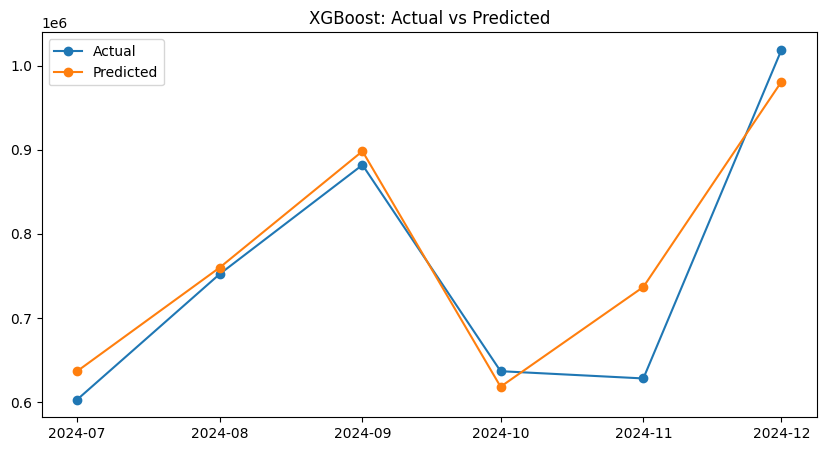

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    comparison_xgb.index,
    comparison_xgb['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    comparison_xgb.index,
    comparison_xgb['Predicted'],
    marker='o',
    label='Predicted'
)

plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.show()

In [141]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_xgb.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
6,rolling_3,0.271921
5,lag_3,0.192387
4,lag_2,0.190233
3,lag_1,0.141909
7,rolling_6,0.109987
1,year_num,0.052650
0,month_num,0.040914
2,quarter,0.000000


In [142]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8915402756884534


In [143]:
future_dates = pd.date_range(
    start='2025-01-01',
    periods=6,
    freq='MS'
)

future_dates

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01'],
              dtype='datetime64[ns]', freq='MS')

In [144]:
future_df = pd.DataFrame(index=future_dates)

future_df['month_num'] = future_df.index.month
future_df['year_num'] = future_df.index.year
future_df['quarter'] = future_df.index.quarter

future_df

,month_num,year_num,quarter
2025-01-01,1,2025,1
2025-02-01,2,2025,1
2025-03-01,3,2025,1
2025-04-01,4,2025,2
2025-05-01,5,2025,2
2025-06-01,6,2025,2


In [145]:
monthly_expense[['amount']].tail(6)

,amount
date,
2024-07-01,603031.0
2024-08-01,752356.0
2024-09-01,881933.0
2024-10-01,636971.0
2024-11-01,628371.0
2024-12-01,1018688.0


In [146]:
monthly_expense[['amount']].tail(3)

,amount
date,
2024-10-01,636971.0
2024-11-01,628371.0
2024-12-01,1018688.0


In [147]:
last_6 = monthly_expense['amount'].tail(6).tolist()
last_6

[603031.0, 752356.0, 881933.0, 636971.0, 628371.0, 1018688.0]

In [148]:
future_df.loc['2025-01-01', 'lag_1'] = last_6[-1]
future_df.loc['2025-01-01', 'lag_2'] = last_6[-2]
future_df.loc['2025-01-01', 'lag_3'] = last_6[-3]

future_df.loc['2025-01-01', 'rolling_3'] = sum(last_6[-3:]) / 3
future_df.loc['2025-01-01', 'rolling_6'] = sum(last_6) / 6

future_df.head(1)

,month_num,year_num,quarter,lag_1,lag_2,lag_3,rolling_3,rolling_6
2025-01-01,1,2025,1,1018688.0,628371.0,636971.0,761343.333333,753558.333333
